# *Respuesta Dinámica Sistema SDOF*

**`Grupo 3 | Integrantes:`** 

- Hernán David Bacca Cárdiles.
- Luis Orlando Delgado Realpe.
- Sergio Daniel Martínez Segura.


**`Materia:`** Dinámica de estructuras.  
**`Pregrado:`** Ingeniería civil.     
**`Institución:`** Universidad Nacional de Colombia.  
**`Docente:`** Juan Pablo Herrera Castaño.  

---  
---  

<p align="center">
  <img src="sistema_b.png">
</p>

### | *Cálculo de respuesta*

#### 1. *Se importan los módulos necesarios*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tabulate import tabulate

#### 2. *Condiciones iniciales y párametros del sistema:*


In [2]:
x0 = 0.1                        # Desplazamiento inicial  [m]
v0 = 5                          # Velocidad inicial       [m/s]

m  = 2750                       # Masa del sistema        [kg]
k  = 444884.9489397             # rigidez del sistema     [N/m]
wn = np.sqrt(k/m)               # Frecuencia natural      [rad/s]

#### 3. *Se define la función principal de cálculo:* 

Función que permite calcular el desplazamiento, velocidad y aceleración del sistema mediante sus respectivas funciones, la cual, contiene como párametros: el intervalo de tiempo y ξ deseado.

In [3]:
def sistema_masa_resorte(xi, t):
    wd = wn*np.sqrt(1 - xi**2)   # Frecuencia natural amortiguada
    
    # Cálculo del desplazamiento
    x = np.exp(-xi*wn*t) * (x0*np.cos(wd*t) + ((v0 + xi*wn*x0)/(wd))*np.sin(wd*t))
    
    # Cálculo de la velocidad
    v = np.exp(-xi*wn*t) * (
        -wn*xi*(x0*np.cos(wd*t) + (v0 + xi*wn*x0)/(wd)*np.sin(wd*t)) +
        wd*(-x0*np.sin(wd*t) + (v0 + xi*wn*x0)/(wd)*np.cos(wd*t))
    )
    
    # Cálculo de la aceleración 
    a = np.exp(-xi*wn*t)*(
        (wn*xi)**2*(x0*np.cos(wd*t) + (v0 + xi*wn*x0)/(wd)*np.sin(wd*t)) +
        2*wn*xi*wd*(x0*np.sin(wd*t) - (v0 + xi*wn*x0)/(wd)*np.cos(wd*t)) +
        wd**2*(-x0*np.cos(wd*t) - (v0 + xi*wn*x0)/(wd)*np.sin(wd*t))
    )
    
    return x, v, a

#### 4. *Preparación de argumentos y cálculo:*

In [4]:
t = np.linspace(0, 5, 1000)        # Tiempo de simulación
xi_valores = [0.0, 0.05, 0.25]     # Valores de xi a simular

resultados = {}                    # Vamos separando la memoria para guardar los resultados en un diccionario

# Calcular resultados para cada valor de xi

for xi in xi_valores:
    # Guardamos los tres arrays (x, v, a) en el diccionario como una tupla para cada valor de xi
    resultados[xi] = sistema_masa_resorte(xi, t)

#### 5. *Gráficas de respuesta para cada ξ*

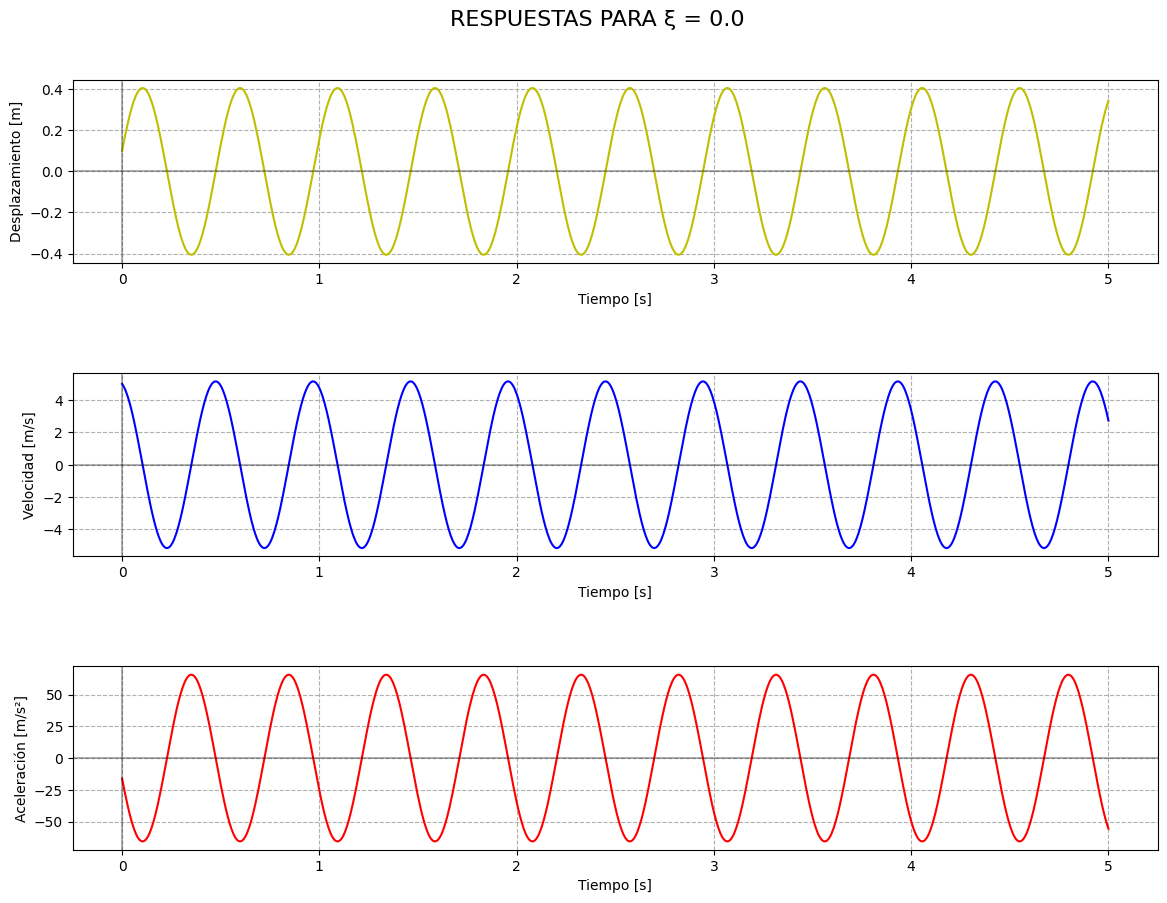

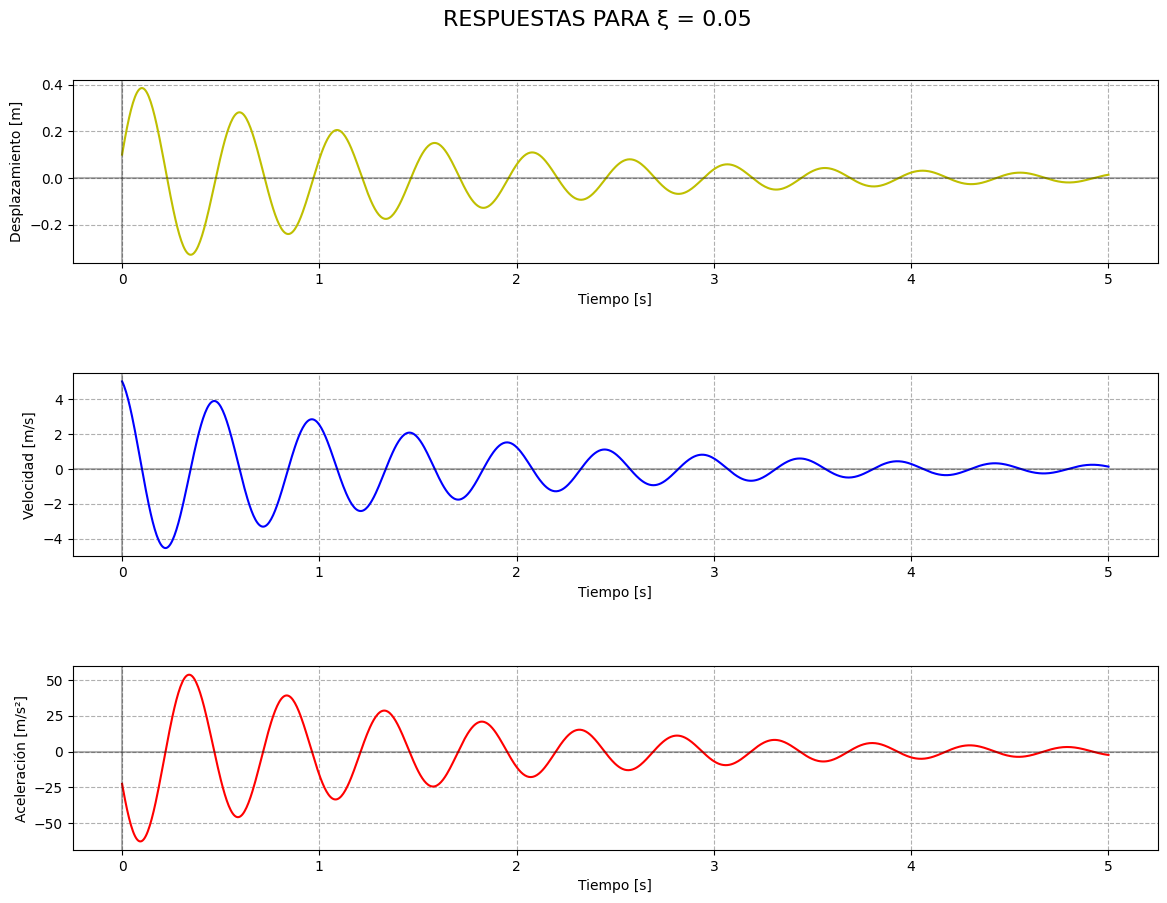

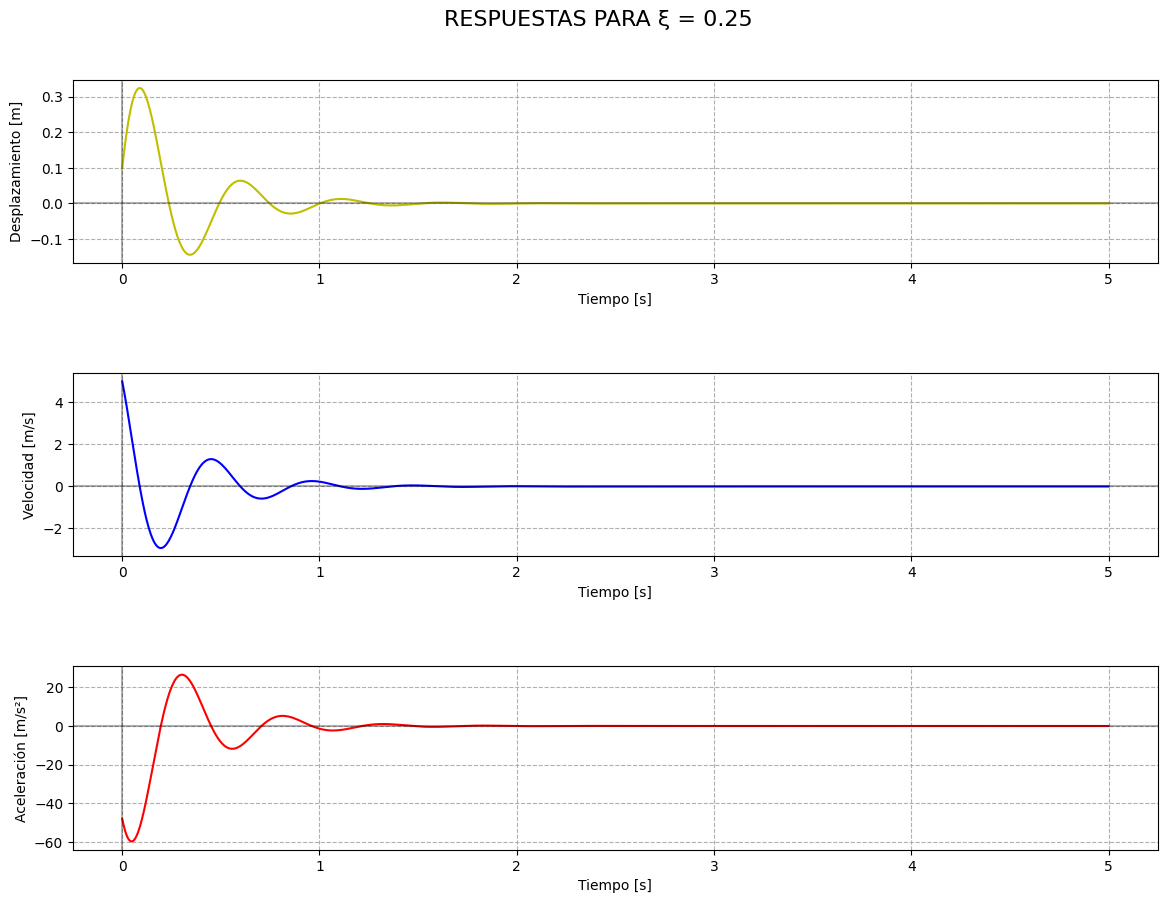

In [5]:
for xi in xi_valores:
    # Crear una figura con tres subplots para cada xi
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10))
    fig.suptitle(f"RESPUESTAS PARA ξ = {xi}", fontsize=16, y=0.95)
    
    # Desplazamiento
    ax1.plot(t, resultados[xi][0], "y-", label="Desplazamiento")
    ax1.axhline(y=0, color="k", linestyle="-", alpha=0.3)
    ax1.axvline(x=0, color="k", linestyle="-", alpha=0.3)
    ax1.set_xlabel("Tiempo [s]")
    ax1.set_ylabel("Desplazamiento [m]")
    ax1.grid(True, linestyle="--")
    
    # Velocidad
    ax2.plot(t, resultados[xi][1], "b-", label="Velocidad")
    ax2.axhline(y=0, color="k", linestyle="-", alpha=0.3)
    ax2.axvline(x=0, color="k", linestyle="-", alpha=0.3)
    ax2.set_xlabel("Tiempo [s]")
    ax2.set_ylabel("Velocidad [m/s]")
    ax2.grid(True, linestyle="--")
    
    # Aceleración
    ax3.plot(t, resultados[xi][2], "r-", label="Aceleración")
    ax3.axhline(y=0, color="k", linestyle="-", alpha=0.3)
    ax3.axvline(x=0, color="k", linestyle="-", alpha=0.3)
    ax3.set_xlabel("Tiempo [s]")
    ax3.set_ylabel("Aceleración [m/s²]")
    ax3.grid(True, linestyle="--")
    
    plt.subplots_adjust(hspace=0.6)    # Aumenta el espacio vertical entre gráficas
    plt.show()

### | *Comparación de resultados*

#### 1. *Gráficas de comparación:*

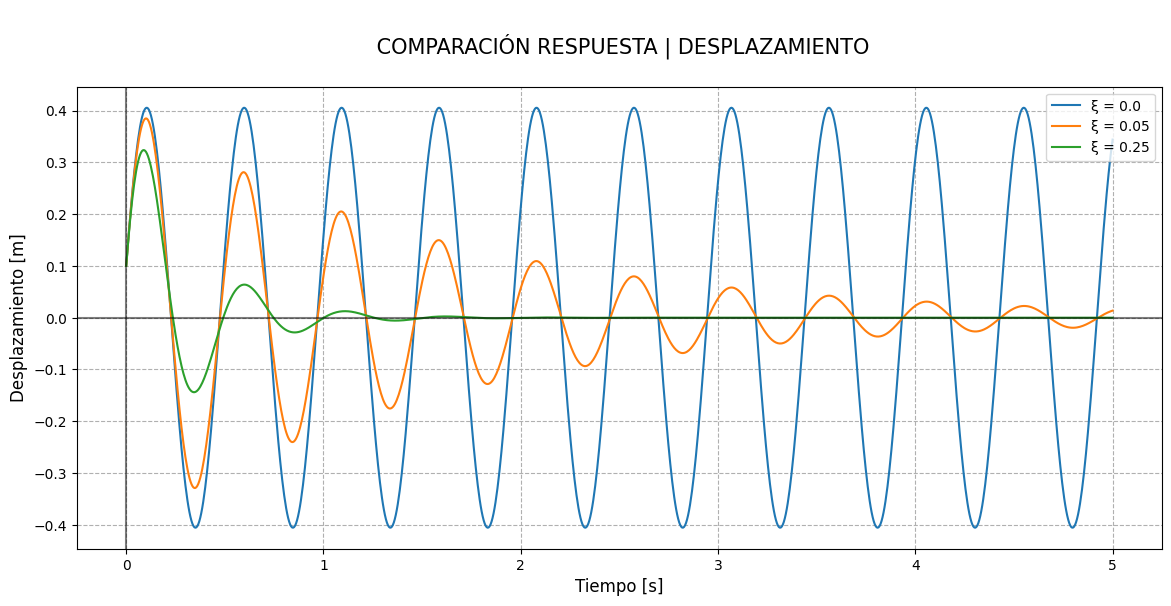

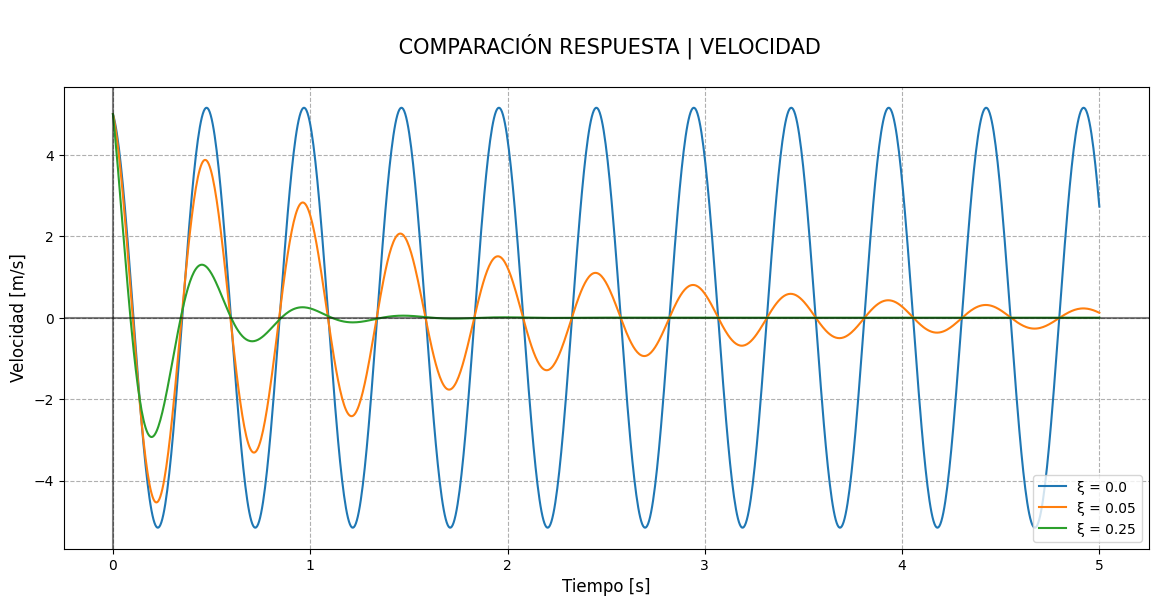

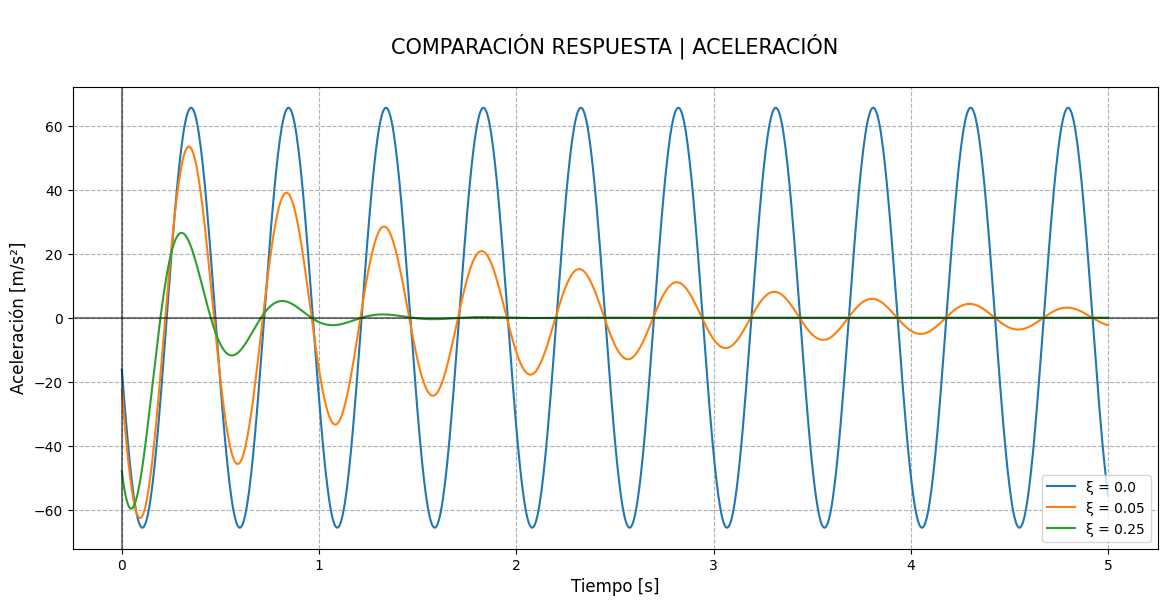

In [6]:
# Gráfica del Desplazamiento
plt.figure(figsize=(14, 6))

for xi in xi_valores:
    plt.plot(t, resultados[xi][0], label=f"ξ = {xi}")

# Configurar la gráfica
plt.xlabel("Tiempo [s]", fontsize=12)
plt.ylabel("Desplazamiento [m]", fontsize=12)
plt.title("\n COMPARACIÓN RESPUESTA | DESPLAZAMIENTO\n", fontsize=15)
plt.grid(True, linestyle="--")
plt.legend(fontsize=10)
plt.axhline(y=0, color="k", linestyle="-", alpha=0.5)
plt.axvline(x=0, color="k", linestyle="-", alpha=0.5)
plt.show()

# Gráfica de la Velocidad
plt.figure(figsize=(14, 6))
for xi in xi_valores:
    plt.plot(t, resultados[xi][1], label=f"ξ = {xi}")

plt.axhline(y=0, color="k", linestyle="-", alpha=0.5)
plt.axvline(x=0, color="k", linestyle="-", alpha=0.5)
plt.xlabel("Tiempo [s]", fontsize=12)
plt.ylabel("Velocidad [m/s]", fontsize=12)
plt.title("\n COMPARACIÓN RESPUESTA | VELOCIDAD\n", fontsize=15)
plt.grid(True, linestyle="--")
plt.legend(fontsize=10)
plt.show()

# Gráfica de la Aceleración
plt.figure(figsize=(14, 6))
for xi in xi_valores:
    plt.plot(t, resultados[xi][2], label=f"ξ = {xi}")

plt.axhline(y=0, color="k", linestyle="-", alpha=0.5)
plt.axvline(x=0, color="k", linestyle="-", alpha=0.5)
plt.xlabel("Tiempo [s]", fontsize=12)
plt.ylabel("Aceleración [m/s²]", fontsize=12)
plt.title("\nCOMPARACIÓN RESPUESTA | ACELERACIÓN\n", fontsize=15)
plt.grid(True, linestyle="--")
plt.legend(fontsize=10)
plt.show()

#### 2. *Cálculo del tiempo en llegar al reposo y valores máximos:*

In [7]:
def encontrar_tiempo_reposo(t, x):
    abs_x = np.abs(x)                               # Obtenemos el valor absoluto de los desplazamientos
    for i, val in enumerate(abs_x):
        if all(v <= 0.001 for v in abs_x[i:]):      # Si todos los valores siguientes son <= 1 mm
            return t[i]                             # Retorneme ese último valor
    return t[-1]                                    # Si no encuentra nada, retorna el último porque el sistema no llegó al reposo

resultados_comp = []                                # Se separa la memoria
for xi in xi_valores:
    x, v, a = resultados[xi]                        # Se guardan los resultados
    
    x_max = np.max(np.abs(x))                       # Se encuentran los valores máximos de cada respuésta  para cada ξ                      
    v_max = np.max(np.abs(v))
    a_max = np.max(np.abs(a))
    
    t_reposo = encontrar_tiempo_reposo(t, x)        # Se encuentra el tiempo de reposo para cada ξ
    
    # Se crea un diccionario con las respuéstas encontradas
    resultados_comp.append({
        "ξ": f"{xi:.3f}",
        "Desplazamiento Máximo [m]" : f"{x_max:.4f}",
        "Velocidad Máxima [m/s]"    : f"{v_max:.4f}",
        "Aceleración Máxima [m/s²]" : f"{a_max:.4f}",
        "Tiempo de reposo [s]"      : f"{t_reposo:.4f}"
    })                         
    

df_resultados = pd.DataFrame(resultados_comp)      # Se pasan los datos a DataFrame usando Pandas para crear tablas más estéticas

# Se crea e imprime la tabla con los resultados

print("\nTabla de Valores Máximos y Tiempo de reposo")
print("="*100)
print(tabulate(df_resultados, headers="keys", tablefmt="fancy_grid", stralign="center", numalign="center", showindex=False))


Tabla de Valores Máximos y Tiempo de reposo
╒══════╤═════════════════════════════╤══════════════════════════╤═════════════════════════════╤════════════════════════╕
│  ξ   │  Desplazamiento Máximo [m]  │  Velocidad Máxima [m/s]  │  Aceleración Máxima [m/s²]  │  Tiempo de reposo [s]  │
╞══════╪═════════════════════════════╪══════════════════════════╪═════════════════════════════╪════════════════════════╡
│  0   │           0.4056            │          5.1592          │           65.621            │           5            │
├──────┼─────────────────────────────┼──────────────────────────┼─────────────────────────────┼────────────────────────┤
│ 0.05 │           0.3851            │            5             │           62.5781           │           5            │
├──────┼─────────────────────────────┼──────────────────────────┼─────────────────────────────┼────────────────────────┤
│ 0.25 │           0.3238            │            5             │           59.664            │         1.91

#### 3. *Cálculo diferencias relativas en valores máximos:*

In [8]:
# Función para calcular diferencias porcentuales entre dos casos:

def calcular_diferencias(caso1, caso2, xi1, xi2):
    diferencias = {}                                                       # Se crea un diccionario    
    diferencias["ξ₁"] = f"{xi1:.4f}"                                       # Ingresamos al diccionario cada ξ
    diferencias["ξ₂"] = f"{xi2:.4f}"
    
    # Bucle que accede a los datos en el DataFrame creado anteriormente
    
    for columna in ["Desplazamiento Máximo [m]", "Velocidad Máxima [m/s]", "Aceleración Máxima [m/s²]"]:   
        val1 = float(caso1[columna])                                       # Se coge una fila completa
        val2 = float(caso2[columna])                                       # Se coge otra fila completa
        
        diff_porcentual = ((val2 - val1)/val1)*100                         # Error relativo entre el valor 2 con respecto al 1
        
        nombre_simple = columna.split("[")[0].strip()                      # Linea para borrar la parte de las unidades del encabezado de las columnas
        diferencias[f"Δ% en {nombre_simple}"] = f"{diff_porcentual:.6f}"   # Se guardan los resultados en el diccionario
    
    return diferencias

# Calcular las compraciones de los datos máximos

comparaciones = []                                                  # Separamos nuevamente memoria 

for i in range(len(xi_valores)):                                  # Bucle anidado para comparar los valores de xi 
    for j in range(i+1, len(xi_valores)):                           # ξ=0 con ξ=0.05 , ξ=0 con ξ=0.25, ξ=0.05 con ξ=0.25 
        caso1 = df_resultados.iloc[i]                               # Se obtienen las filas correspondientes
        caso2 = df_resultados.iloc[j]
        
        # Se cálcula el error
        comparacion = calcular_diferencias(caso1, caso2, xi_valores[i], xi_valores[j])  
        comparaciones.append(comparacion)

df_comparaciones = pd.DataFrame(comparaciones)                     # Se pasan los datos a DataFrame usando Pandas para crear tablas más estéticas  

print("\nTabla de Diferencias Relativas entre Casos")
print("="*100)
print(tabulate(df_comparaciones, headers="keys", tablefmt="fancy_grid", stralign="center", numalign="center", showindex=False))

# Notas explicativas
print("\nNotas:")
print("- Δ% representa el diferencia relativa del segundo caso (ξ₂) respecto al primer caso (ξ₁).")
print("- Valores negativos indican una reducción en el segundo caso.")


Tabla de Diferencias Relativas entre Casos
╒══════╤══════╤═══════════════════════════════╤══════════════════════════╤════════════════════════════╕
│  ξ₁  │  ξ₂  │  Δ% en Desplazamiento Máximo  │  Δ% en Velocidad Máxima  │  Δ% en Aceleración Máxima  │
╞══════╪══════╪═══════════════════════════════╪══════════════════════════╪════════════════════════════╡
│  0   │ 0.05 │           -5.05424            │         -3.08575         │          -4.63708          │
├──────┼──────┼───────────────────────────────┼──────────────────────────┼────────────────────────────┤
│  0   │ 0.25 │           -20.1677            │         -3.08575         │          -9.07789          │
├──────┼──────┼───────────────────────────────┼──────────────────────────┼────────────────────────────┤
│ 0.05 │ 0.25 │           -15.9179            │            0             │          -4.65674          │
╘══════╧══════╧═══════════════════════════════╧══════════════════════════╧════════════════════════════╛

Notas:
- Δ% represe

#### 4. *Cálculo errores absotulos entre ξ=0.05 y ξ=0.25*

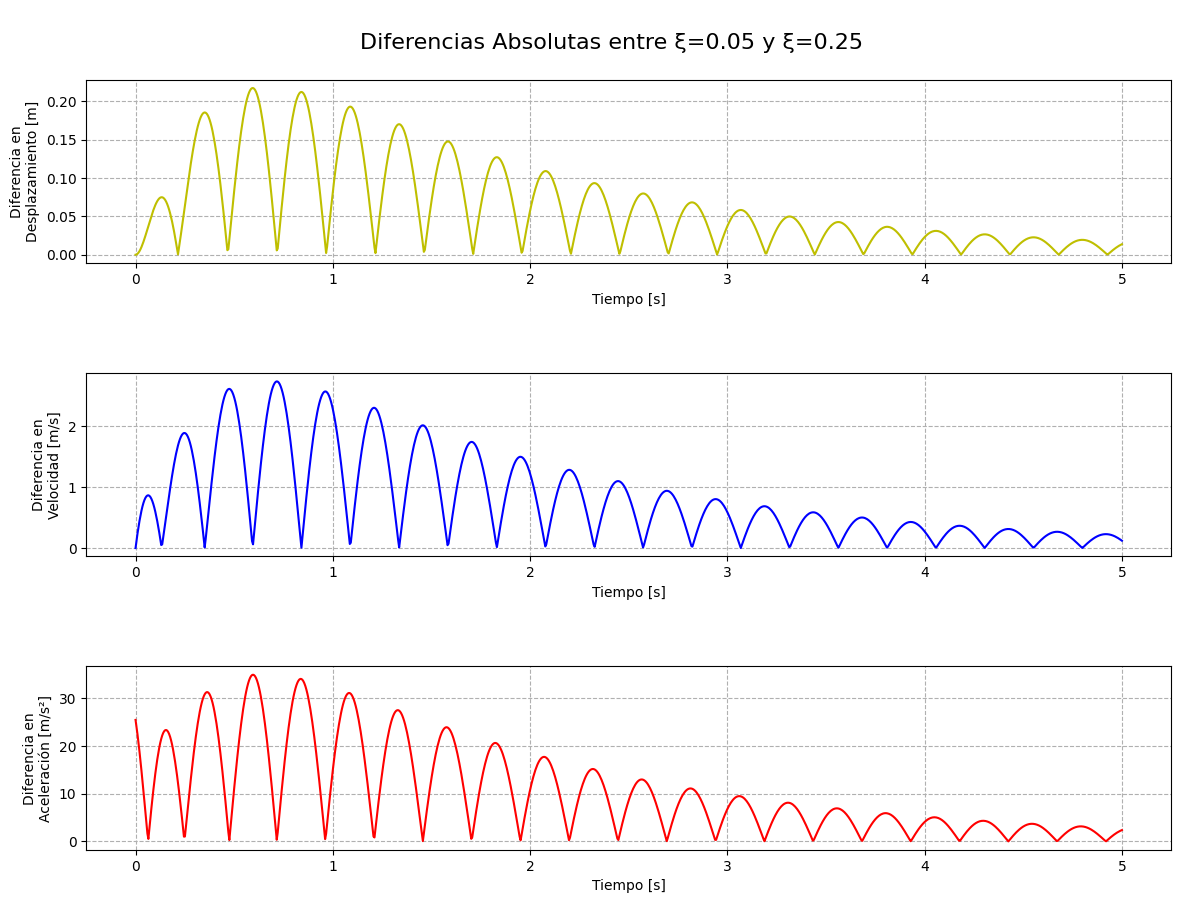


Diferencias absolutas máximas y abslutas:
Diferencia máxima en desplazamiento:     0.2172 m
Diferencia máxima en velocidad:          2.7393 m/s
Diferencia máxima en aceleración:        34.8999 m/s²

Diferencia promedio en desplazamiento:   0.062 m
Diferencia promedio en velocidad:        0.7881 m/s
Diferencia promedio en aceleración:      10.2877 m/s²


In [9]:
x_005, v_005, a_005 = resultados[0.05]         
x_025, v_025, a_025 = resultados[0.25]

diff_x = np.abs(x_025 - x_005)                                       # Calculamos las diferencias absolutas
diff_v = np.abs(v_025 - v_005)
diff_a = np.abs(a_025 - a_005)

# Creamos las tres gráficas
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle("\nDiferencias Absolutas entre ξ=0.05 y ξ=0.25\n", fontsize=16, y=0.95)

# Gráfica de diferencia en desplazamiento
ax1.plot(t, diff_x, "y-", label="|x₀.₂₅ - x₀.₀₅|")
ax1.set_xlabel("Tiempo [s]")
ax1.set_ylabel("Diferencia en\nDesplazamiento [m]")
ax1.grid(True, linestyle="--")


# Gráfica de diferencia en velocidad
ax2.plot(t, diff_v, "b-", label="|v₀.₂₅ - v₀.₀₅|")
ax2.set_xlabel("Tiempo [s]")
ax2.set_ylabel("Diferencia en\nVelocidad [m/s]")
ax2.grid(True, linestyle="--")


# Gráfica de diferencia en aceleración
ax3.plot(t, diff_a, "r-", label="|a₀.₂₅ - a₀.₀₅|")
ax3.set_xlabel("Tiempo [s]")
ax3.set_ylabel("Diferencia en\nAceleración [m/s²]")
ax3.grid(True, linestyle="--")

plt.subplots_adjust(hspace=0.6)    # Aumenta el espacio vertical entre gráficas
plt.show()

# Imprimir algunos datos estadísticos de las diferencias
print("\nDiferencias absolutas máximas y abslutas:")
print("="*60)
print(f"Diferencia máxima en desplazamiento:     {np.max(diff_x):.4f} m")
print(f"Diferencia máxima en velocidad:          {np.max(diff_v):.4f} m/s")
print(f"Diferencia máxima en aceleración:        {np.max(diff_a):.4f} m/s²")
print(f"\nDiferencia promedio en desplazamiento:   {np.mean(diff_x):.3f} m")
print(f"Diferencia promedio en velocidad:        {np.mean(diff_v):.4f} m/s")
print(f"Diferencia promedio en aceleración:      {np.mean(diff_a):.4f} m/s²")

### | *Fuerzas actuantes del sistema*

<p align="center">
  <img src="ec2.png">
</p>

#### 1. *Calculo y gráfico de las fuerzas del sistema:*

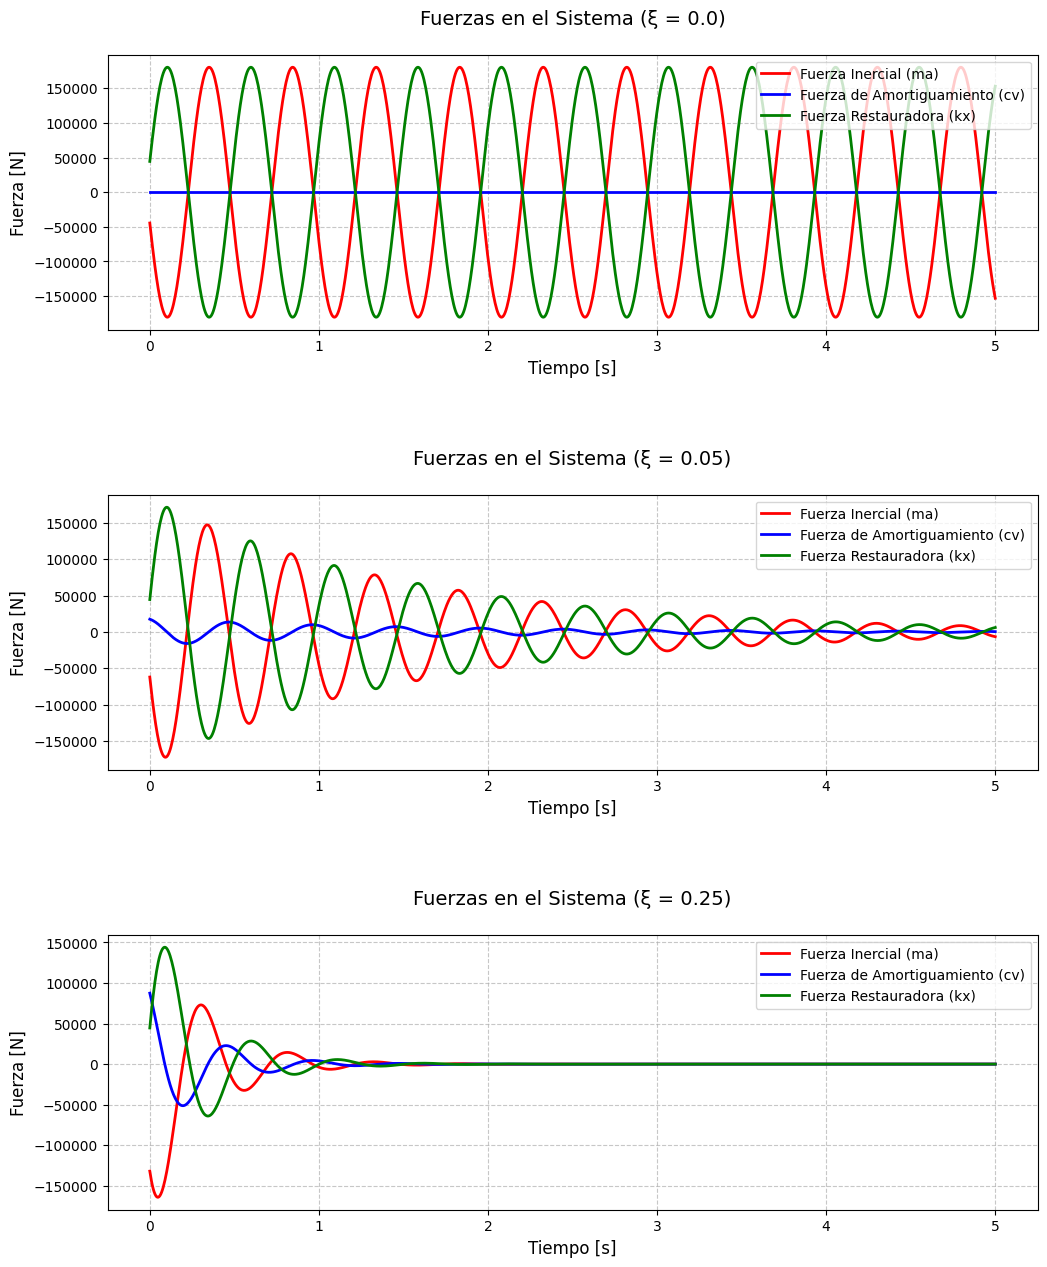


Valores máximos de las fuerzas (ξ = 0.0):
Fuerza inercial máxima: 180457.8715 N
Fuerza amortiguamiento máxima: 0.0000 N
Fuerza restauradora máxima: 180457.8715 N

Valores máximos de las fuerzas (ξ = 0.05):
Fuerza inercial máxima: 172089.7785 N
Fuerza amortiguamiento máxima: 17488.8079 N
Fuerza restauradora máxima: 171309.0131 N

Valores máximos de las fuerzas (ξ = 0.25):
Fuerza inercial máxima: 164075.8734 N
Fuerza amortiguamiento máxima: 87444.0396 N
Fuerza restauradora máxima: 144048.7863 N


In [10]:
fuerzas = {}                      # Se separa la memoria para un diccionario

# Se cálculan las fuerzas para cada ξ
for xi in xi_valores:  
    # Se obtienen x, v, a del diccionario de resultados 
    x, v, a = resultados[xi]
    
    # Calcular c para el xi actual
    c = 2*xi*wn*m
    
    # Calcular las fuerzas para el xi actual
    fuerzas[xi] = {
        "inercial": m*a,
        "amortiguamiento": c*v,
        "restauradora": k*x
    }

# Crear las gráficas
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 15))
axes = [ax1, ax2, ax3]

# Graficar para cada xi
for ax, xi in zip(axes, xi_valores):
    ax.plot(t, fuerzas[xi]["inercial"], "r-", label="Fuerza Inercial (ma)", linewidth=2)
    ax.plot(t, fuerzas[xi]["amortiguamiento"], "b-", label="Fuerza de Amortiguamiento (cv)", linewidth=2)
    ax.plot(t, fuerzas[xi]["restauradora"], "g-", label="Fuerza Restauradora (kx)", linewidth=2)
    
    ax.set_title(f"Fuerzas en el Sistema (ξ = {xi})\n", fontsize=14)
    ax.set_xlabel("Tiempo [s]", fontsize=12)
    ax.set_ylabel("Fuerza [N]", fontsize=12)
    ax.grid(True, linestyle="--", alpha=0.7)
    ax.legend(fontsize=10)

plt.subplots_adjust(hspace=0.6)    # Aumenta el espacio vertical entre gráficas
plt.show()

# Imprimir valores máximos
for xi in xi_valores:
    print(f"\nValores máximos de las fuerzas (ξ = {xi}):")
    print("="*50)
    for tipo_fuerza in fuerzas[xi]:
        max_fuerza = np.max(np.abs(fuerzas[xi][tipo_fuerza]))
        print(f"Fuerza {tipo_fuerza} máxima: {max_fuerza:.4f} N")

#### 2. *Comprobación principio de Alembert:*

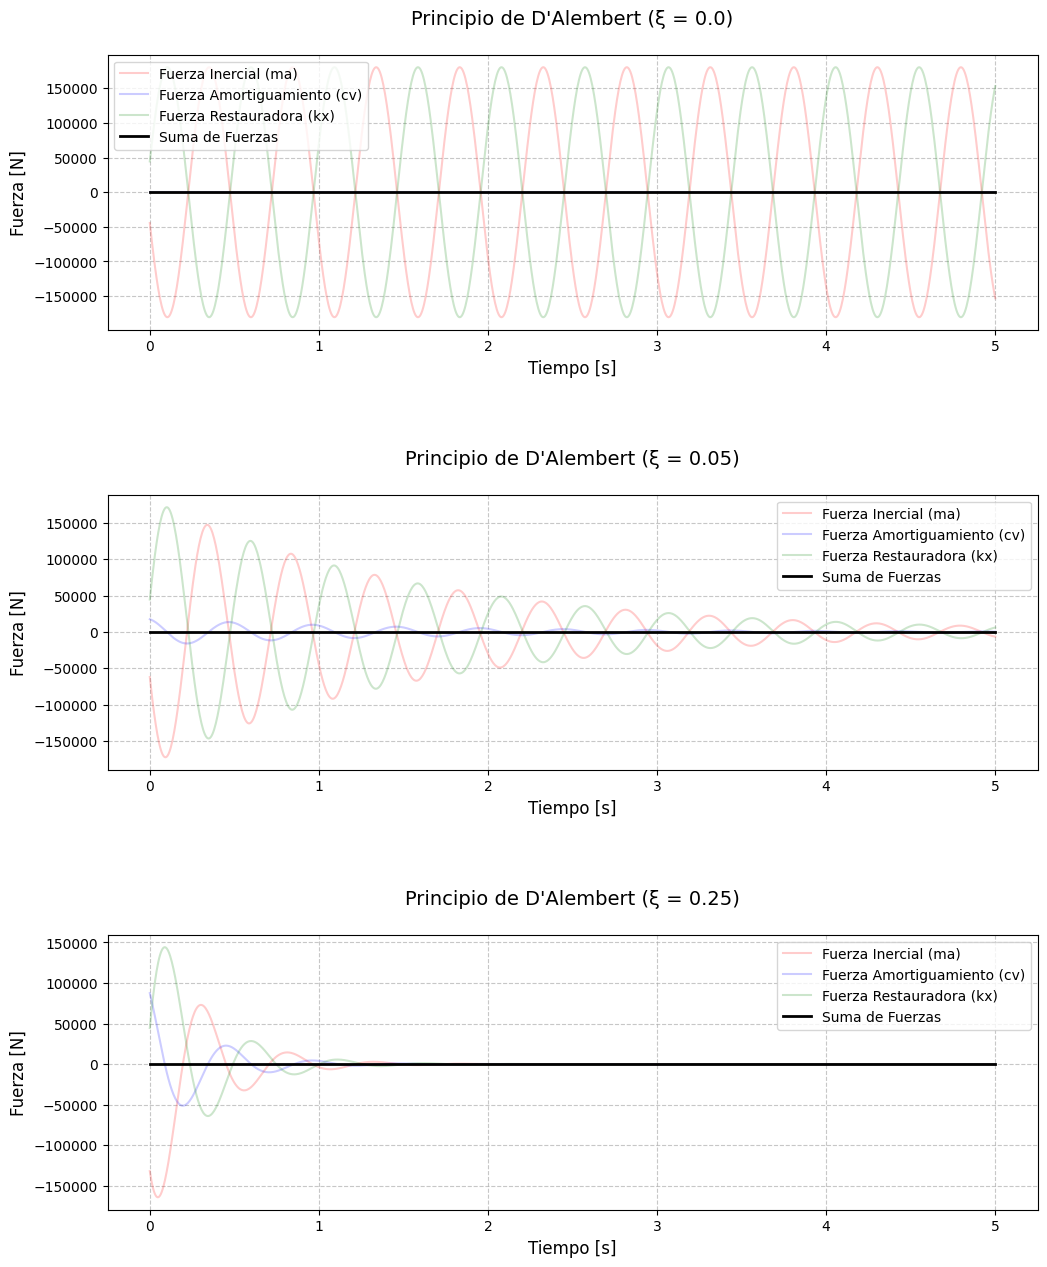


Verificación del Principio de D'Alembert:

Para ξ = 0.0:
Error máximo: 2.91e-11 N
Error promedio: 8.02e-12 N

Para ξ = 0.05:
Error máximo: 2.91e-11 N
Error promedio: 3.30e-12 N

Para ξ = 0.25:
Error máximo: 2.91e-11 N
Error promedio: 1.22e-12 N


In [11]:
# Se crea la figura y los sub-gráficos

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 15))
axes = [ax1, ax2, ax3]

# Graficar para cada xi
for ax, xi in zip(axes, xi_valores):
    # Sumar todas las fuerzas (deberían dar aproximadamente cero)
    suma_fuerzas = (fuerzas[xi]["inercial"] + 
                    fuerzas[xi]["amortiguamiento"] + 
                    fuerzas[xi]["restauradora"])
    
    # Graficar las fuerzas individuales y su suma
    ax.plot(t, fuerzas[xi]["inercial"]       , "r-"  , label="Fuerza Inercial (ma)"        , alpha=0.2)
    ax.plot(t, fuerzas[xi]["amortiguamiento"], "b-"  , label="Fuerza Amortiguamiento (cv)" , alpha=0.2)
    ax.plot(t, fuerzas[xi]["restauradora"]   , "g-"  , label="Fuerza Restauradora (kx)"    , alpha=0.2)
    ax.plot(t, suma_fuerzas                  , "k-"  , label="Suma de Fuerzas"             , linewidth=2)
    
    ax.set_title(f"Principio de D'Alembert (ξ = {xi})\n", fontsize=14)
    ax.set_xlabel("Tiempo [s]", fontsize=12)
    ax.set_ylabel("Fuerza [N]", fontsize=12)
    ax.grid(True, linestyle="--", alpha=0.7)
    ax.legend(fontsize=10)

plt.subplots_adjust(hspace=0.6)    # Aumenta el espacio vertical entre gráficas
plt.show()


# Se imprime el error máximo para cada caso
print("\nVerificación del Principio de D'Alembert:")
print("="*50)
for xi in xi_valores:
    suma_fuerzas = (fuerzas[xi]["inercial"] + 
                    fuerzas[xi]["amortiguamiento"] + 
                    fuerzas[xi]["restauradora"])
    error_max = np.max(np.abs(suma_fuerzas))
    error_promedio = np.mean(np.abs(suma_fuerzas))
    print(f"\nPara ξ = {xi}:")
    print(f"Error máximo: {error_max:.2e} N")
    print(f"Error promedio: {error_promedio:.2e} N")